# Policy Iteration
In this notebook, you are going to implement a policy-based approach for solving a MDP, called _Policy Iteration_.

The total points of **_Policy Iteration_** implementation is **30 POINTS**.

## Import the necessary software libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from gridworld import Environment
from utils import plot_policy, plot_values, test_agent

pygame 2.5.2 (SDL 2.28.3, Python 3.11.4)
Hello from the pygame community. https://www.pygame.org/contribute.html


## Initialize the environment

In [2]:
env = Environment()
state = env.reset()

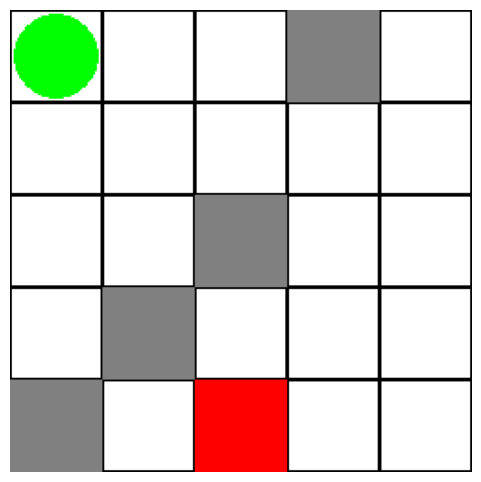

In [3]:
frame = env.render()
plt.figure(figsize=(6,6))
plt.axis('off')
plt.imshow(frame)

In [4]:
print(f"Observation space shape: {env.observation_space.nvec}")
print(f"Number of actions: {env.action_space.n}")

Observation space shape: [5 5]
Number of actions: 4


## Define the policy $\pi(\cdot|s)$

#### Create the policy $\pi(\cdot|s)$

In [5]:
policy_probs = np.full((env.GH, env.GW, 4), 0.25)

In [6]:
def policy(state):
    return policy_probs[state]

#### Test the policy with state (0, 0)

In [7]:
action_probabilities = policy((0,0))
for action, prob in zip(range(4), action_probabilities):
    print(f"Probability of taking action {action}: {prob}")

Probability of taking action 0: 0.25
Probability of taking action 1: 0.25
Probability of taking action 2: 0.25
Probability of taking action 3: 0.25


#### See how the random policy does in the maze

In [8]:
# test_agent(env, policy, episodes=1)

#### Plot the policy

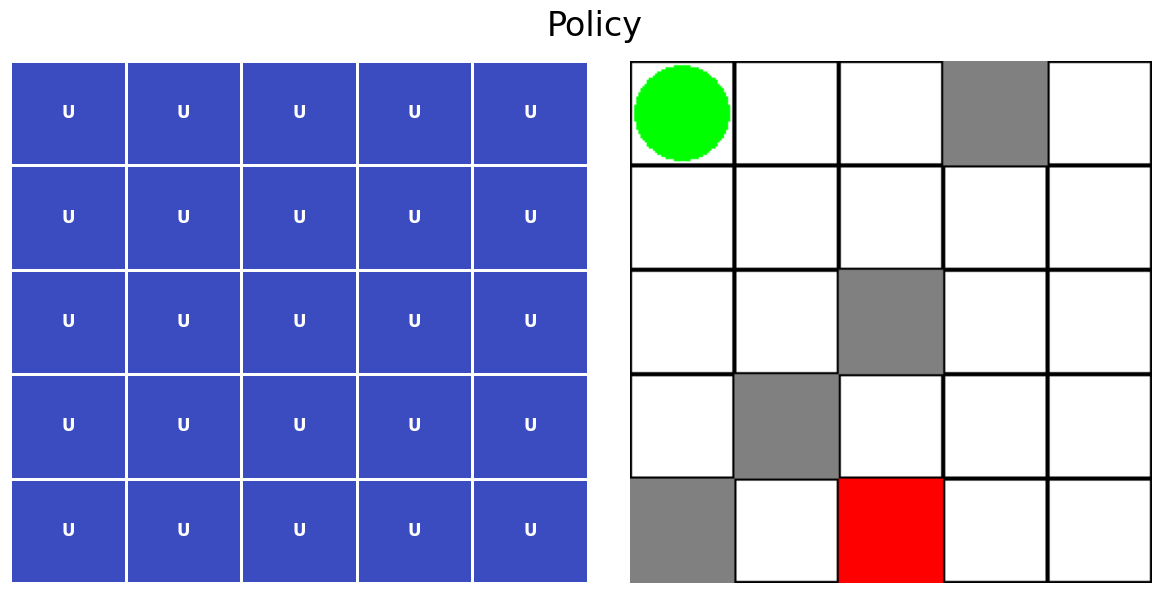

In [9]:
plot_policy(policy_probs, frame)

## Implement the Policy Iteration algorithm
<!-- <div style="text-align:center"> -->
<a target="_parent">
    <img src="policy-iteration.png" width="60%"/>
</a> 

Adapted from Barto & Sutton: "Reinforcement Learning: An Introduction".
<!-- </div> -->


In [19]:
def policy_evaluation(policy_probs, state_values, theta=1e-6, gamma=0.99):
    #TODO: You need to implement the component of Policy Evaluation here (15 points).
    print("In eval")
    #for each state in S
    for row in range(env.GH):
        for col in range(env.GW):
            eval_count=0
                            
            #loop until the break is triggered
            while True and env.noCollision(col,row):
                eval_count+=1
                
                #reset delta
                delta=0
                
                #store this state value before it changes
                v = state_values[row,col]
                    
                #Determine what action the policy dictates
                next_act=np.argmax(policy_probs[row,col,:])
                
                #get outputs from simulated step
                test_state, test_reward, test_terminal, test_info = env.simulate_step((row,col),next_act)
                
                #Determine what the V(s') should be
                if test_terminal:
                    Vsp=0
                else:
                    #if not at the goal, find V(s') = Vsp
                    Vsp=state_values[test_state]
                
                #update the State value
                state_values[row,col]=1*(test_reward+gamma*Vsp)
                
                #print("Evaluation iter: ",eval_count, "; Row: ",row,"; Col: ",col,"; Old state_val: ", v,"; New state_val: ",state_values[row,col], "; Difference: ",abs(v-state_values[row,col]))
                
                delta=max(delta,abs(v-state_values[row,col]))
                #print(delta)
                if delta<theta:
                    break
        
    
    #TODO: Add comments to explain your code
    return

In [20]:
def policy_improvement(policy_probs, state_values, gamma=0.99):
    #TODO: You need to implement the component of Policy Improvement here (15 points).
    print("In Improvement")
    #Set a variable to see if anything changed
    pol_unchanged = True
    
    #run a for loop through every state
    for row in range(env.GH):
        for col in range(env.GW):
            
            #get the current policy
            old_action=np.argmax(policy_probs[row,col,:])
            
            #update the policy probs
            if env.noCollision(col,row):
                for act in range(env.ACTIONS):
                        
                    #get outputs from simulated step
                    test_state, test_reward, test_terminal, test_info = env.simulate_step((row,col),act)
                        
                    if test_terminal:
                        Vsp=0
                    else:
                        #if not at the goal, find V(s') = Vsp
                        Vsp=state_values[test_state]
                            
                    #Update the policy_probs
                    policy_probs[(row,col,act)]=1*(test_reward+gamma*Vsp)
                    
            #if the max action changed, return false
            if old_action!=np.argmax(policy_probs[row,col,:]):
                pol_unchanged = False
                
    #If still true raise the max to 1 and the others to zero
    #set the max position to 1 and others to 0
    for row in range(env.GH):
        for col in range(env.GW):
            row_max=np.max(policy_probs[row,col,:])
                    
            max_set=False
                    
            for act in range(env.ACTIONS):
                if policy_probs[row,col,act]==row_max and not max_set:
                    policy_probs[row,col,act]=1
                    max_set=True
                else:
                    policy_probs[row,col,act]=0
    
    #TODO: Add comments to explain your code
    return pol_unchanged

In [21]:
def policy_iteration(policy_probs, state_values, theta=1e-6, gamma=0.99):
    # putting Policy Iteration and Policy Improvement together
    policy_stable = False
    iteration_count=0
    while not policy_stable:
        iteration_count+=1
        print("Iteration: ",iteration_count)
        policy_evaluation(policy_probs, state_values, theta, gamma)
        policy_stable = policy_improvement(policy_probs, state_values, gamma)
        


In [22]:
env = Environment()
state = env.reset()
state_values = np.zeros(shape=(env.GH,env.GW))
#TODO: You need to call the Policy Iteration algorithm here
policy_iteration(policy_probs, state_values) 
print(policy_probs)

Iteration:  1
In eval
In Improvement
Iteration:  2
In eval
In Improvement
Iteration:  3
In eval
In Improvement
Iteration:  4
In eval
In Improvement
Iteration:  5
In eval
In Improvement
Iteration:  6
In eval
In Improvement
Iteration:  7
In eval
In Improvement
Iteration:  8
In eval
In Improvement
[[[0. 1. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [1. 0. 0. 0.]
  [0. 0. 1. 0.]]

 [[0. 1. 0. 0.]
  [0. 1. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]]

 [[1. 0. 0. 0.]
  [1. 0. 0. 0.]
  [1. 0. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]]

 [[1. 0. 0. 0.]
  [1. 0. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]]

 [[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [1. 0. 0. 0.]
  [0. 0. 0. 1.]
  [0. 0. 0. 1.]]]


## Show results

#### Show resulting value table $V(s)$

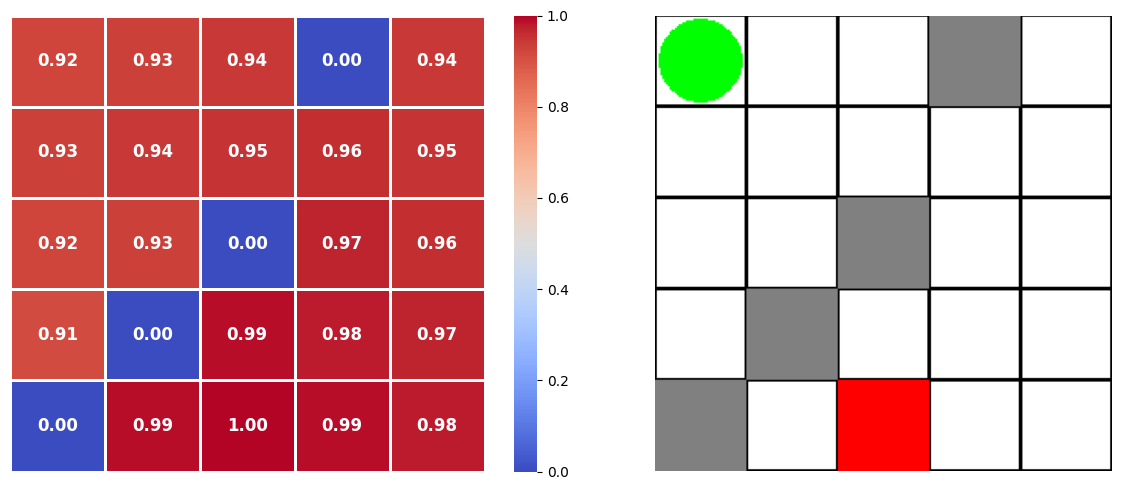

In [23]:
plot_values(state_values, frame)

#### Show resulting policy $\pi(\cdot|s)$

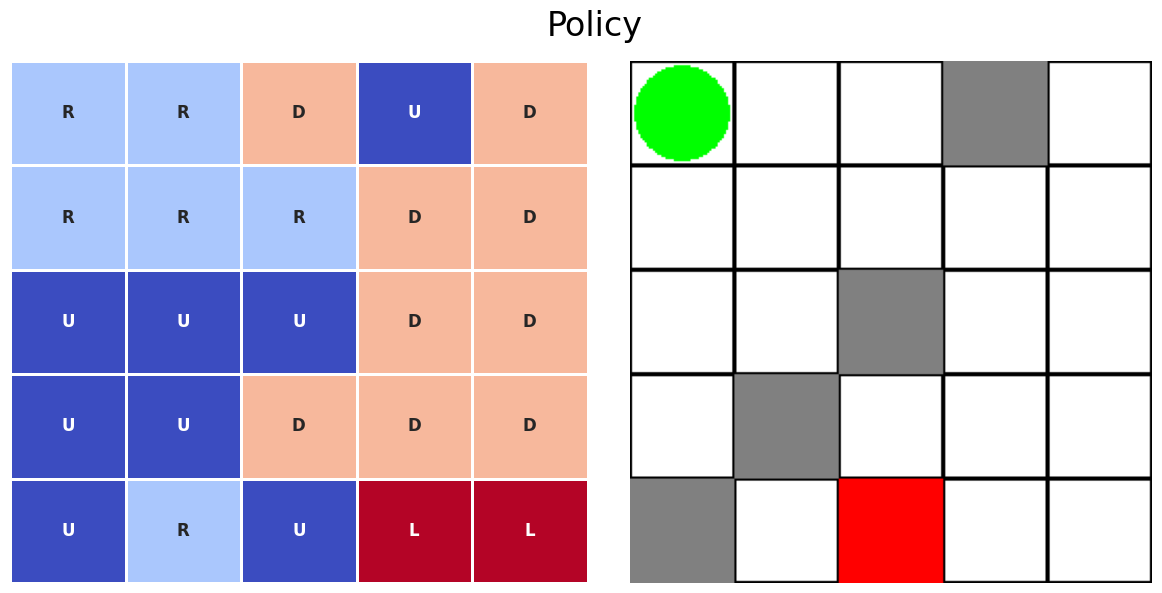

In [24]:
plot_policy(policy_probs, frame)

#### Test the resulting agent

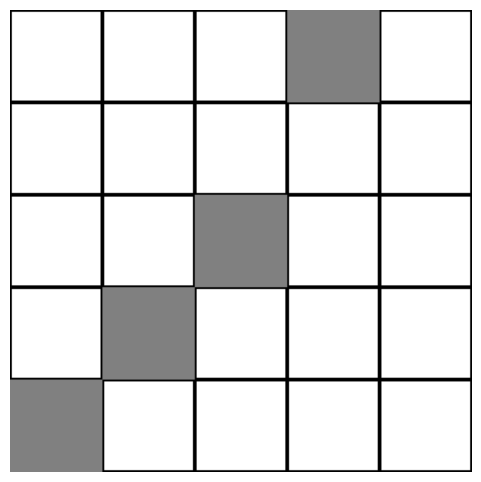

In [25]:
test_agent(env, policy, episodes=1)